In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import os
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use("spectral_analysis/visualization/mystyle.mplstyle")
import json
with open("config.json") as f:
    config = json.load(f)

In [2]:
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
# df['PPL_mcg/L'] = 1000*df['PPL_mcg/L']
df = df[df['task']==config["task"]]
df.columns

Index(['subject', 'raw_id', 'session', 'task', 'run', 'age', 'sex',
       'drug_admin_time', 'ppl_time', 'sdi_time', 'asl_start_time',
       'scan_start_time', 'scan_end_time', 'scan_min_since_admin',
       'ppl_min_since_admin', 'sdi_min_since_admin', 'asl_min_since_admin',
       'ppl_min_since_scan', 'sdi_min_since_scan', 'asl_min_since_scan',
       'PPL_mcg/L', 'SDI', 'time_interval', 'tr', 'te', 'num_vols', 'ped',
       'coil_name', 'coil_active', 'scanner', 'include_scan_coil_numvols',
       'include_manual_qc', 'ratio_outliers_fd0.5_std_dvars1000', 'mean_fd',
       'mean_std_dvars', 'max_fd', 'outlier_locs', 'scan_filename',
       'preproc_filename_volumetric', 'preproc_filename_cifti',
       'preproc_filename_cifti_despiked', 'preproc_filename_cifti_aroma',
       'asl_filename'],
      dtype='str')

In [3]:
# filter out rows where include_scan is due to missing head coil or interrupted scan
df = df[df['include_scan_coil_numvols']]
df = df[df['include_manual_qc']]
# for the purpose of visualization, set negative values of scan_min_since_admin to 0
df['scan_min_since_admin'] = df['scan_min_since_admin'].clip(lower=0)
# make a new column where subjects get new names, e.g., Subject 1, Subject 2, etc.
df['subject_clean'] = df['subject'].astype('category')
df['subject_clean'] = df['subject_clean'].cat.rename_categories(['Subject {}'.format(i) for i in range(1, len(df['subject_clean'].cat.categories) + 1)])

print('Number of scans included: ', len(df))

Number of scans included:  153


In [4]:
# print the number of scans for each subject
print(df['subject'].value_counts())

subject
sub-55162    10
sub-56722    10
sub-56726    10
sub-56733    10
sub-57132    10
sub-55809     8
sub-56145     7
sub-56017     6
sub-53888     5
sub-55965     5
sub-55988     5
sub-55992     5
sub-56030     5
sub-56061     5
sub-56114     5
sub-56118     5
sub-56122     5
sub-56141     5
sub-57131     5
sub-57142     5
sub-57193     5
sub-57214     5
sub-55772     4
sub-55729     3
sub-55746     2
sub-56165     2
sub-57218     1
Name: count, dtype: int64


## Line plots of the acute psilocybin experience
These plots only contain measurements with an associated included rs-fmri scan

In [5]:
subjects = df['subject_clean'].unique()
markers = {subject: 'o' for subject in subjects}

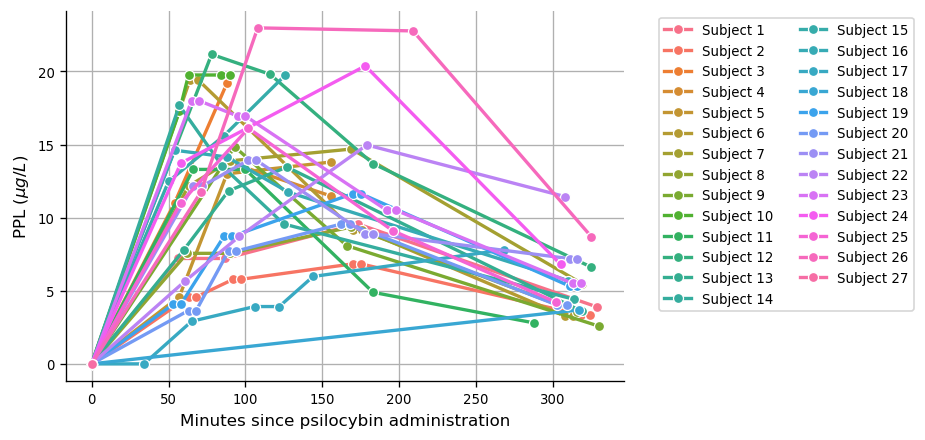

In [6]:
sns.lineplot(data=df, x='scan_min_since_admin', y='PPL_mcg/L', hue='subject_clean', style='subject_clean', markers=markers, dashes=False)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.xlabel('Minutes since psilocybin administration')
plt.ylabel(r'PPL ($\mu g/L$)');

In [7]:
intervals = config['time_intervals']
interval_elements = list(intervals.values())
bins = np.sort(np.unique(interval_elements))
intervals_labels = list(intervals.keys())
intervals_labels2 = [f"{label} ({start}-{end} min)" for label, (start, end) in intervals.items()]
intervals_labels2[0] = 'Predrug (0-20 min)'  # change the first label to reflect that we set negative values to 0
intervals_labels2[-1] = 'Return (250+ min)'  # change the last label to reflect the new interval

In [8]:
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2 = df2[df2['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
df2 = df2[df2['max_fd'] < config["scan_max_fd_threshold"]]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

scan_counts = df2.groupby('time_bin').size().reset_index(name='Number of Scans')
print(scan_counts)

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  26
1      Upslope (20-80 min)                  18
2        Peak (80-150 min)                  17
3  Downslope (150-250 min)                  13
4        Return (250+ min)                  21
       Total number of scans: 125
                  time_bin  Number of Scans
0       Predrug (0-20 min)               33
1      Upslope (20-80 min)               23
2        Peak (80-150 min)               25
3  Downslope (150-250 min)               17
4        Return (250+ min)               27


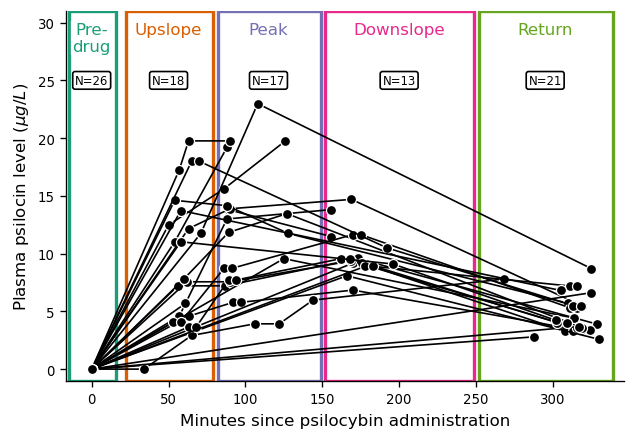

In [9]:
ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(False)

ax.set_ylim(-1,31)
sns.lineplot(data=df2, x='scan_min_since_admin', y='PPL_mcg/L', style='subject_clean',color='k',linewidth=1, markers=markers, dashes=False, legend=False, ax=ax)
cols = sns.color_palette("Dark2",n_colors=5)
# add rectuangular boxes in specified time-windows. Only the box outline should be visible
Ns = subject_counts['Number of Subjects'].values
for i,name in enumerate(intervals):
    if name == 'Predrug':
        start, end = -17,17
        name = 'Pre-\ndrug'
    elif name == 'Return':
        start, end = 250, 340
    else:
        start, end = intervals[name]
    ax.add_patch(plt.Rectangle((start+2, plt.ylim()[0]), end-3 - start, 
                                      plt.ylim()[1] - plt.ylim()[0], 
                                      fill=False, edgecolor=cols[i], linestyle='-', linewidth=2))
    ax.text((start + end)/2, plt.ylim()[1]*0.97, name, horizontalalignment='center', verticalalignment='top', 
             color=cols[i], fontsize=10, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'))
    plt.text((start + end)/2, 25, 'N='+str(Ns[i]), horizontalalignment='center', verticalalignment='center', fontsize=7,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))


ax.set_xlabel('Minutes since psilocybin administration')
ax.set_ylabel(r'Plasma psilocin level ($\mu g/L$)');
plt.savefig('figures/ppl_timecourse_all_subjects.png', bbox_inches='tight')

Text(0, 0.5, 'Subject drug intensity (SDI)')

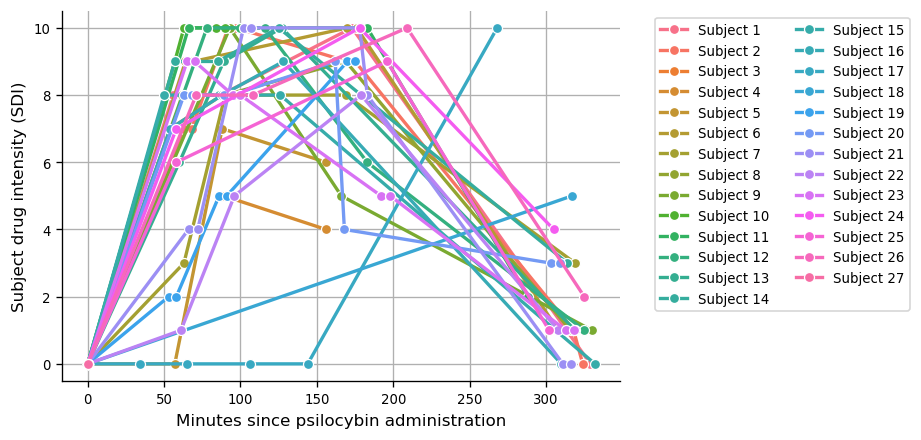

In [10]:
sns.lineplot(data=df, x='scan_min_since_admin', y='SDI', hue='subject_clean', style='subject_clean', markers=markers, dashes=False)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.xlabel('Minutes since psilocybin administration')
plt.ylabel('Subject drug intensity (SDI)')

Count the number of subjects with a scan at 0min, 20-80min, 80-150min, 150-270min, 270+min

In [11]:
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df['scan_min_since_admin'] = df['scan_min_since_admin'].clip(lower=0)

In [12]:
df['time_bin'] = pd.cut(df['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df)))

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  28
1      Upslope (20-80 min)                  27
2        Peak (80-150 min)                  27
3  Downslope (150-250 min)                  20
4        Return (250+ min)                  24
       Total number of scans: 170


In [13]:
df2 = df[df['include_scan_coil_numvols']]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  28
1      Upslope (20-80 min)                  27
2        Peak (80-150 min)                  27
3  Downslope (150-250 min)                  18
4        Return (250+ min)                  24
       Total number of scans: 165


In [14]:
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  26
1      Upslope (20-80 min)                  24
2        Peak (80-150 min)                  24
3  Downslope (150-250 min)                  18
4        Return (250+ min)                  22
       Total number of scans: 153


In [15]:
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2 = df2[df2['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  26
1      Upslope (20-80 min)                  21
2        Peak (80-150 min)                  20
3  Downslope (150-250 min)                  17
4        Return (250+ min)                  22
       Total number of scans: 142


In [16]:
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2 = df2[df2['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
df2 = df2[df2['max_fd'] < config["scan_max_fd_threshold"]]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=intervals_labels2)
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

                  Time Bin  Number of Subjects
0       Predrug (0-20 min)                  26
1      Upslope (20-80 min)                  18
2        Peak (80-150 min)                  17
3  Downslope (150-250 min)                  13
4        Return (250+ min)                  21
       Total number of scans: 125


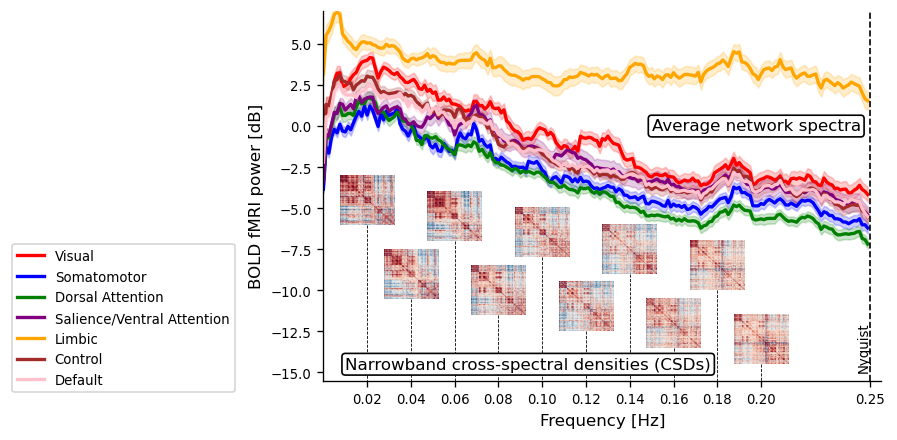

In [17]:
from spectral_analysis.helper_functions import import_mask_and_parcellation
parcel_labels = import_mask_and_parcellation(config['parcellation'])[0]
networks_colors = config['networks_colors']

region_names = np.loadtxt('data/external/Schaefer2018_200Parcels_7Networks_order_label.txt',dtype=str, usecols=0)
# include only every second row
region_names = region_names[::2]
network_names = ['_Vis','_SomMot','_DorsAttn','_SalVentAttn','_Limbic','_Cont','_Default']
region_to_network = []
for network in network_names:
    network_idx = [i for i, name in enumerate(region_names) if network in name]
    region_to_network.append(np.array(network_idx)+1)

spectra = np.loadtxt('data/spectra/9p/sub-53888/ses-PSI/func/sub-53888_ses-PSI_task-rest_acq-ep2d_dir-AP_run-1_space-fsLR_den-91k_bold_mtspectra_parcellated_'+config['parcellation']+'.txt')
spectra = spectra[:-1]
frequencies = np.loadtxt('data/frequencies_MR45.txt')[:-1]
# spectra is a F x region array, region names given above, we need to make a datafra
df = pd.DataFrame(spectra, columns=region_names)
# add frequency column
df['Frequency [Hz]'] = frequencies
# melt the dataframe to long format
df_melted = df.melt(id_vars=['Frequency [Hz]'], var_name='region', value_name='BOLD fMRI power [dB]')
# add network column
def get_network(region):
    for i, network in enumerate(network_names):
        if network in region:
            return network
df_melted['network'] = df_melted['region'].apply(get_network)
# df_melted
# # I need to plot every single region colored by network
for i,n in enumerate(network_names):
    network_regions = df_melted[df_melted['network'] == n]
    sns.lineplot(data=network_regions, x='Frequency [Hz]', y='BOLD fMRI power [dB]', color=networks_colors[i], legend=False, errorbar='se')
plt.ylim(-15.5,7)
plt.xlim(0,0.255)
ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(False)
spacing = 4.5
increment = 1
start = -4.5
heights = [start, start-spacing, start-increment, start-increment-spacing, start-2*increment, start-2*increment-spacing
           , start-3*increment, start-3*increment-spacing, start-4*increment, start-4*increment-spacing]
height = 3
width = 0.025
for i,freqs in enumerate([0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]):
    # read png image and place it at the right frequency beneath the other curves
    img = plt.imread(f'figures/narrowband_csd/tmp_{freqs:.2f}Hz_covariance.png')
    # place image at (freqs, -12) with width 0.015 and height 3
    plt.imshow(img, extent=(freqs-width/2, freqs+width/2, heights[i]-height/2, heights[i]+height/2), aspect='auto', zorder=10)
    # add vertical line to the x-axis from the bottom of the image
    plt.plot([freqs, freqs], [heights[i]-height/2, plt.ylim()[0]], color='k', linestyle='--', linewidth=0.5)

# add vertical line at 0.25 Hz saying "Nyquist"
ax.axvline(x=0.25, color='k', linestyle='--', linewidth=1)
plt.text(0.25, -15, 'Nyquist', horizontalalignment='right', verticalalignment='bottom', fontsize=8, rotation=90)

# make a manual legend
plt.xticks([0.02,0.04,0.06,0.08,0.1,0.12,0.14,0.16,0.18,0.2,0.25])
plt.legend_handles = [plt.Line2D([0], [0], color=networks_colors[i], lw=2) for i in range(len(network_names))]
plt.legend_labels = ['Visual','Somatomotor','Dorsal Attention','Salience/Ventral Attention','Limbic','Control','Default']
plt.legend(plt.legend_handles, plt.legend_labels, loc='lower left', ncol=1, bbox_to_anchor=(-0.57, -0.05),fontsize=8)
plt.text(0.01, -14.5, 'Narrowband cross-spectral densities (CSDs)', horizontalalignment='left', verticalalignment='center', fontsize=10,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))
plt.text(0.15, -0, 'Average network spectra', horizontalalignment='left', verticalalignment='center', fontsize=10,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))

plt.savefig('figures/spectral_profiles_schaefer200.png', bbox_inches='tight')

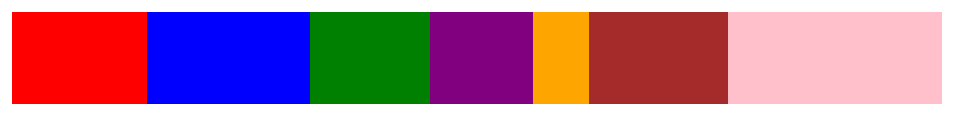

In [18]:
networks_number_of_rois2 = [0]*len(network_names)
for i,n in enumerate(network_names):
    network_regions = [region for region in region_names if n in region]
    networks_number_of_rois2[i] = len(network_regions)
# Create a 1D array that represents the colored boxes
color_boxes = np.zeros((1, 200, 3))

# Assign colors to the corresponding segments
for i, color in enumerate(networks_colors):
    start = sum(networks_number_of_rois2[:i])
    end = start + networks_number_of_rois2[i]
    #use the predefined colors
    color_boxes[0, start:end, :] = plt.cm.colors.to_rgb(color)
    
# Plot the color boxes below the matrix
fig, ax = plt.subplots(1,1, figsize=(10, 1))
ax.imshow(color_boxes, aspect='auto')
ax.grid(False)
ax.axis('off')
plt.savefig('figures/spectral_profiles_schaefer200_colorbar.png', bbox_inches='tight', pad_inches=0)

Processing frequency:  0.02


KeyboardInterrupt: 

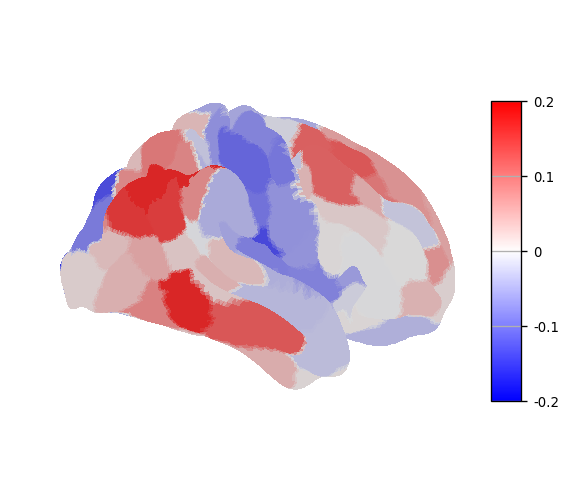

In [19]:
from nilearn import plotting, surface
# evs = evs[:,::-1]
parcel_labels, parcellation, masks, parcellation_extended = import_mask_and_parcellation(config['parcellation'])
# unique_parcels = np.unique(parcellation)
# unique_parcels = unique_parcels[unique_parcels != 0]  # remove background parcel
unique_parcels = np.arange(1, parcel_labels.shape[0]+1)  # use all parcels in parcellation
vmin = -0.2
vmax = 0.2
eigenvector_idx = 0
os.makedirs('figures/ged_examples', exist_ok=True)

# cov_broadband = np.load('data/ged_results/acompcor/sub-53888/ses-PSI/func/sub-53888_ses-PSI_task-rest_acq-ep2d_dir-AP_run-1_space-fsLR_den-91k_bold_ged_broadband_covariance.npy')

# for frequency in np.arange(0.02, 0.21, 0.02):
for frequency in np.arange(0.02,0.04,0.02):
    frequency_str = f"{frequency:.2f}"
    print('Processing frequency: ', frequency_str)
    evs = np.load('data/ged_results/9p/sub-53888/ses-PSI/func/sub-53888_ses-PSI_task-rest_acq-ep2d_dir-AP_run-1_space-fsLR_den-91k_bold_freq_'+frequency_str+'_ged_leading_eigenvectors_rescaled.npy')
    # evs = cov_broadband @ evs
    for eigenvector_idx in range(10):
        ev = evs[:,eigenvector_idx]
        if np.sum(ev>0) > np.sum(ev<0):
            ev *= -1
        avg_map = {}
        for roi_label, roi_number in zip(parcel_labels,unique_parcels):
            avg_map[roi_label] = ev[roi_number-1]
        for hemi in ['lh', 'rh']:
        
            cortex_map = np.empty(masks['mask_'+hemi].shape)
            cortex_map.fill(np.nan)
            for roi_label, roi_number in zip(parcel_labels,unique_parcels):
                if '_'+hemi+'_' in roi_label.lower():
                    cortex_map[parcellation_extended['parcellation_'+hemi+'_expanded']==roi_number] = avg_map[roi_label]
            h = hemi[0].upper()
            if hemi == 'lh':
                h2 = 'left'
            else:
                h2 = 'right'

            fsLR_surface = surface.load_surf_mesh('data/external/fs_LR.32k.'+h+'.midthickness.surf.gii')
            for view in ['lateral']:#,'medial'
                plotting.plot_surf(fsLR_surface,cortex_map,symmetric_cmap=None,bg_on_data=True,colorbar=True, 
                                cmap='bwr', vmin=vmin, vmax=vmax, alpha=1, hemi=h2,view=view)
                plt.savefig('figures/ged_examples/example_leading_eigenvector'+str(eigenvector_idx)+'_'+frequency_str+'_'+hemi+'_'+view+'.png', dpi=300, bbox_inches='tight')
                plt.close()